# 06 — Heatmap y ranking top-N (predicciones recursivas)

### Objetivo
Visualizaciones finales del proyecto usando el **mejor modelo (LightGBM)** segun la validacion del notebook 05, con predicciones **multi-step recursivas** (las que realmente se usarian en produccion).

1. **Heatmap 43x4**: robos reales vs predichos (LightGBM) agregados por (distrito, turno) en el holdout.
2. **Heatmap de error absoluto**: donde se equivoca mas el modelo.
3. **Ranking top-15**: celdas (distrito, turno) con mayor robo predicho.
4. **Serie temporal por top-5 distritos**: real vs predicho semana a semana.
5. **Comparativa LightGBM vs XGBoost**.

Segun la validacion recursiva:
- LightGBM: RMSE = ~0.5 (mas estable)
- XGBoost:  RMSE = ~0.8 (mas variable, se degrada mas con recursion)

In [19]:
# Carga de predicciones del holdout (generadas con recursion en el notebook 05)
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("/Users/guillermo/Downloads/TA_IA_Aplicada/Data")
FIG_DIR = Path("/Users/guillermo/Downloads/TA_IA_Aplicada/Modelado/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / "predicciones_holdout.csv")
print(f"Shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")

Shape: (2064, 7)
Columnas: ['distrito_hecho', 'turno_hecho', 'año_semana', 'semana_global', 'count_robos', 'pred_xgboost', 'pred_lightgbm']


### Seleccion del modelo principal

In [20]:
# LightGBM es el ganador segun CV. Lo usamos como modelo principal.
columna_pred_principal = "pred_lightgbm"
columna_pred_alternativo = "pred_xgboost"
print(f"Modelo principal: {columna_pred_principal}")
print(f"Modelo alternativo: {columna_pred_alternativo}")

# Verificacion rapida: RMSE recursivo de cada modelo en el holdout
y_real = df["count_robos"].values
for col in [columna_pred_principal, columna_pred_alternativo]:
    if col in df.columns:
        rmse_m = np.sqrt(np.mean((y_real - df[col].values) ** 2))
        print(f"  {col}: RMSE recursivo = {rmse_m:.3f}")

Modelo principal: pred_lightgbm
Modelo alternativo: pred_xgboost
  pred_lightgbm: RMSE recursivo = 6.511
  pred_xgboost: RMSE recursivo = 6.482


### Heatmap real vs predicho (LightGBM)

In [21]:
# Agregar por (distrito, turno) sumando las 12 semanas del holdout
agg = (df.groupby(["distrito_hecho", "turno_hecho"])
         .agg(real=("count_robos", "sum"), predicho=(columna_pred_principal, "sum"))
         .reset_index())

pivot_real = agg.pivot(index="distrito_hecho", columns="turno_hecho", values="real").fillna(0)
pivot_pred = agg.pivot(index="distrito_hecho", columns="turno_hecho", values="predicho").fillna(0)

orden_turno = ["madrugada", "mañana", "tarde", "noche"]
pivot_real = pivot_real[orden_turno]
pivot_pred = pivot_pred[orden_turno]

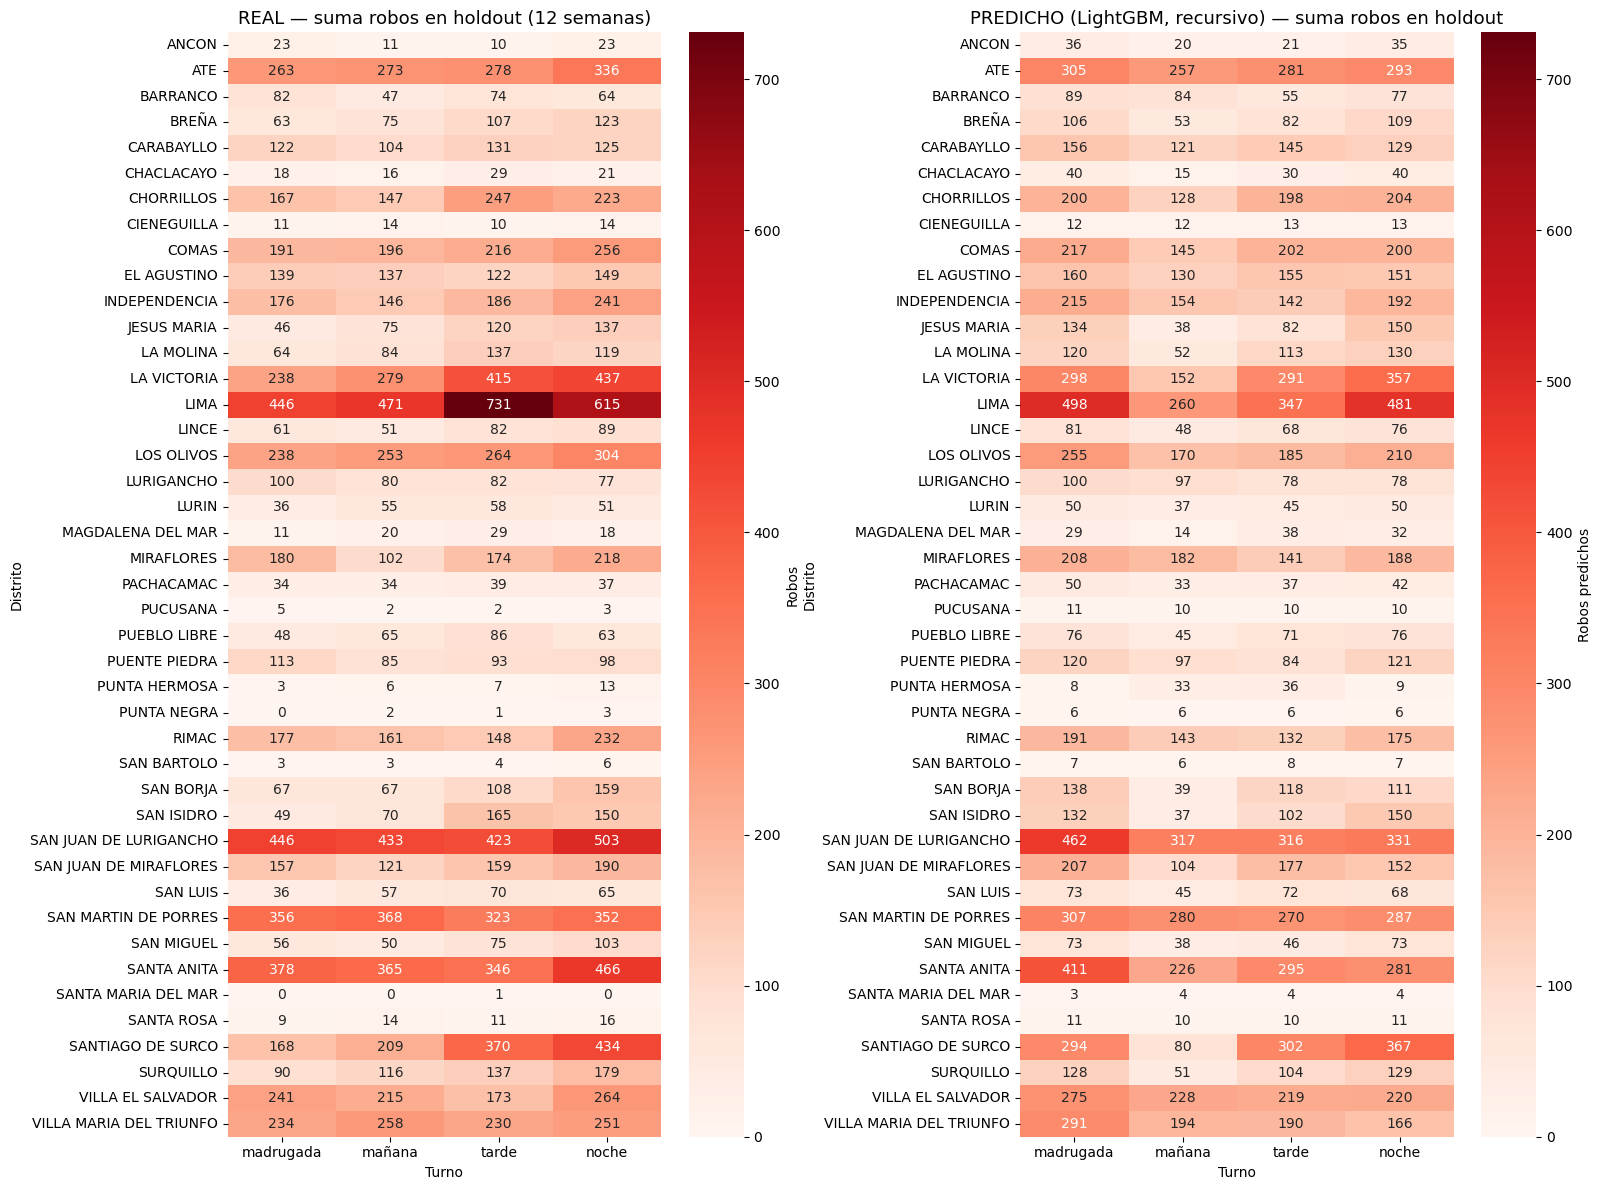

In [22]:
# Heatmaps lado a lado con la misma escala de color
fig, axes = plt.subplots(1, 2, figsize=(16, 12))
vmax = max(pivot_real.values.max(), pivot_pred.values.max())

sns.heatmap(pivot_real, annot=True, fmt=".0f", cmap="Reds", ax=axes[0],
            cbar_kws={"label": "Robos"}, vmin=0, vmax=vmax)
axes[0].set_title("REAL — suma robos en holdout (12 semanas)", fontsize=13)
axes[0].set_xlabel("Turno"); axes[0].set_ylabel("Distrito")

sns.heatmap(pivot_pred, annot=True, fmt=".0f", cmap="Reds", ax=axes[1],
            cbar_kws={"label": "Robos predichos"}, vmin=0, vmax=vmax)
axes[1].set_title(f"PREDICHO (LightGBM, recursivo) — suma robos en holdout", fontsize=13)
axes[1].set_xlabel("Turno"); axes[1].set_ylabel("Distrito")
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_real_vs_predicho.png", dpi=120, bbox_inches="tight")
plt.show()

### Heatmap de error absoluto

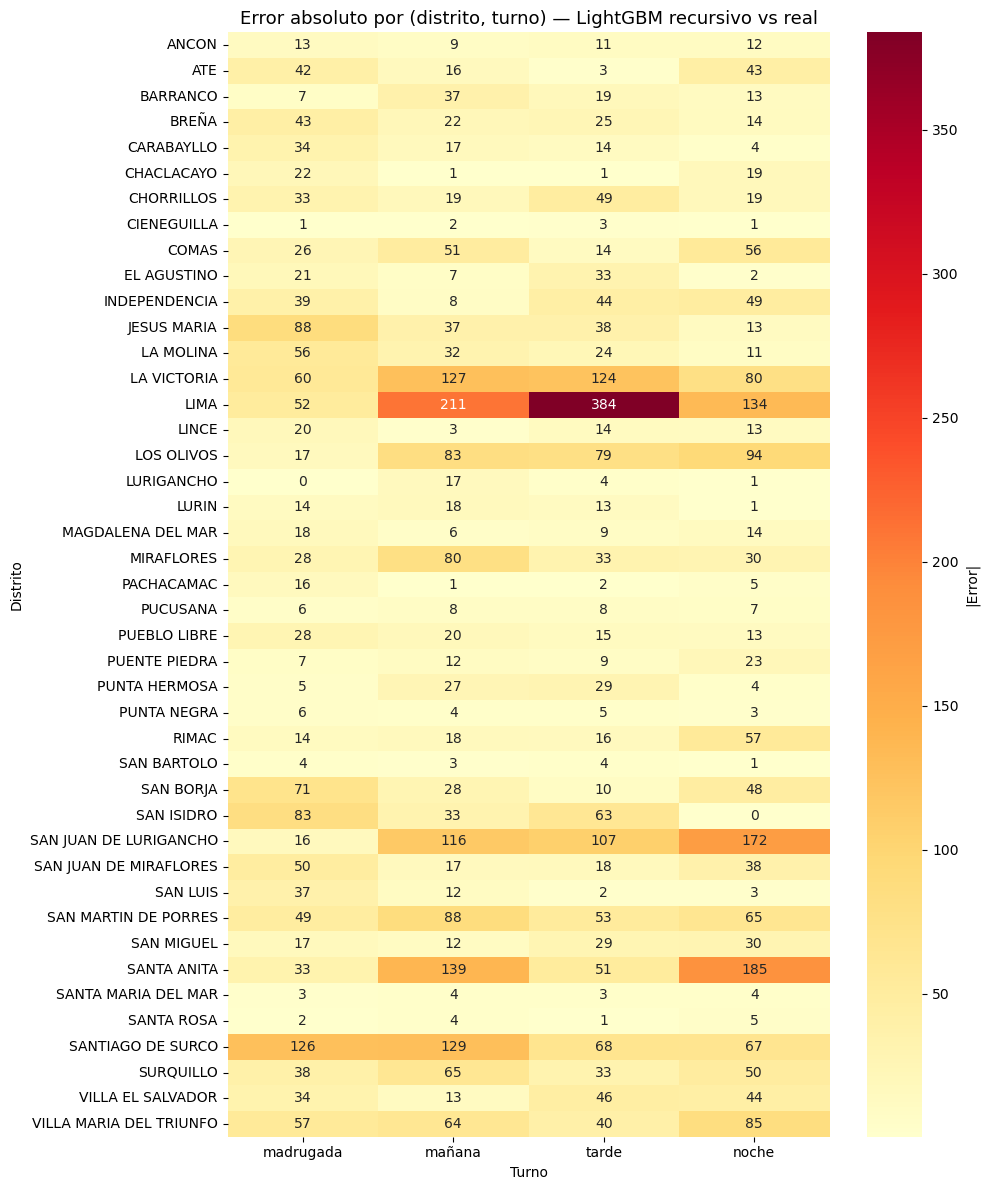

In [23]:
# Magnitud del error por celda (predicho - real en valor absoluto)
error_abs = (pivot_pred - pivot_real).abs()
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(error_abs, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "|Error|"})
ax.set_title("Error absoluto por (distrito, turno) — LightGBM recursivo vs real", fontsize=13)
ax.set_xlabel("Turno"); ax.set_ylabel("Distrito")
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_error_absoluto.png", dpi=120, bbox_inches="tight")
plt.show()

### Ranking top-15

In [24]:
# Top 15 zonas con mayor robo predicho (suma holdout recursivo)
agg["error_abs"] = (agg["real"] - agg["predicho"]).abs()
agg["error_pct"] = 100 * (agg["predicho"] - agg["real"]) / agg["real"].clip(lower=1)

ranking = agg.sort_values("predicho", ascending=False).head(15).reset_index(drop=True)
print("Top 15 zonas con mayor robo predicho (LightGBM recursivo):")
print(ranking.to_string(index=False))
ranking.to_csv(DATA_DIR / "ranking_top15.csv", index=False)

Top 15 zonas con mayor robo predicho (LightGBM recursivo):
        distrito_hecho turno_hecho  real   predicho  error_abs  error_pct
                  LIMA   madrugada   446 498.143670  52.143670  11.691406
                  LIMA       noche   615 481.047641 133.952359 -21.780871
SAN JUAN DE LURIGANCHO   madrugada   446 462.445157  16.445157   3.687255
           SANTA ANITA   madrugada   378 411.435771  33.435771   8.845442
     SANTIAGO DE SURCO       noche   434 367.435164  66.564836 -15.337520
           LA VICTORIA       noche   437 357.285350  79.714650 -18.241339
                  LIMA       tarde   731 347.107409 383.892591 -52.516086
SAN JUAN DE LURIGANCHO       noche   503 331.036549 171.963451 -34.187565
SAN JUAN DE LURIGANCHO      mañana   433 316.658841 116.341159 -26.868628
SAN JUAN DE LURIGANCHO       tarde   423 315.796609 107.203391 -25.343591
  SAN MARTIN DE PORRES   madrugada   356 306.992197  49.007803 -13.766237
                   ATE   madrugada   263 305.210614  

### Series temporales top-5 distritos

In [25]:
# Evolucion semanal real vs predicho para los 5 distritos con mas robos
top5_distritos = agg.groupby("distrito_hecho")["real"].sum().nlargest(5).index.tolist()
print(f"Top 5 distritos: {top5_distritos}")

Top 5 distritos: ['LIMA', 'SAN JUAN DE LURIGANCHO', 'SANTA ANITA', 'SAN MARTIN DE PORRES', 'LA VICTORIA']


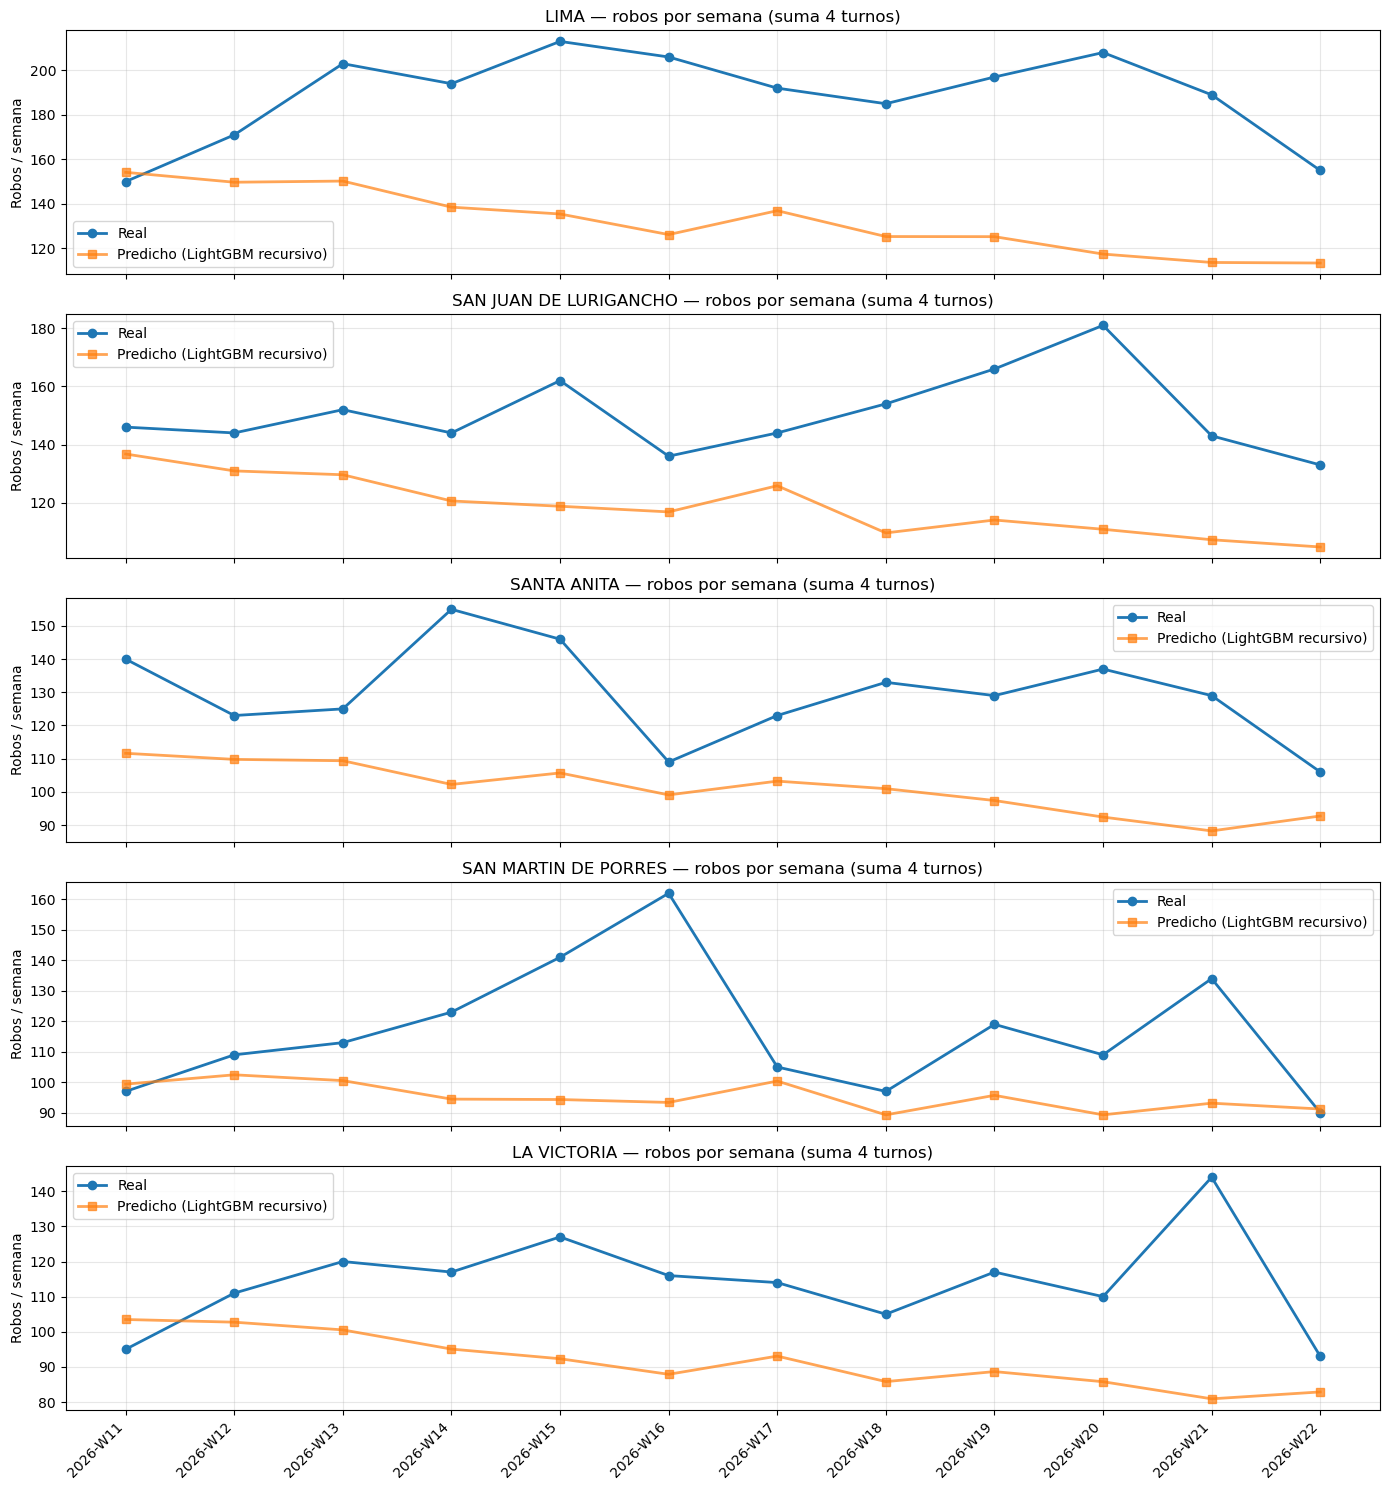

In [26]:
# Plot: 5 subplots, uno por distrito, suma de los 4 turnos por semana
fig, axes = plt.subplots(len(top5_distritos), 1, figsize=(14, 3 * len(top5_distritos)), sharex=True)
if len(top5_distritos) == 1:
    axes = [axes]
for ax, distrito in zip(axes, top5_distritos):
    sub = df[df["distrito_hecho"] == distrito]
    real = sub.groupby("año_semana")["count_robos"].sum()
    pred = sub.groupby("año_semana")[columna_pred_principal].sum()
    ax.plot(real.index, real.values, marker="o", label="Real", lw=2)
    ax.plot(pred.index, pred.values, marker="s", label="Predicho (LightGBM recursivo)", lw=2, alpha=0.7)
    ax.set_title(f"{distrito} — robos por semana (suma 4 turnos)", fontsize=12)
    ax.set_ylabel("Robos / semana"); ax.legend(); ax.grid(True, alpha=0.3)
    for label in ax.get_xticklabels():
        label.set_rotation(45); label.set_ha("right")
plt.tight_layout()
plt.savefig(FIG_DIR / "serie_temporal_top5_distritos.png", dpi=120, bbox_inches="tight")
plt.show()

### Comparativa LightGBM vs XGBoost

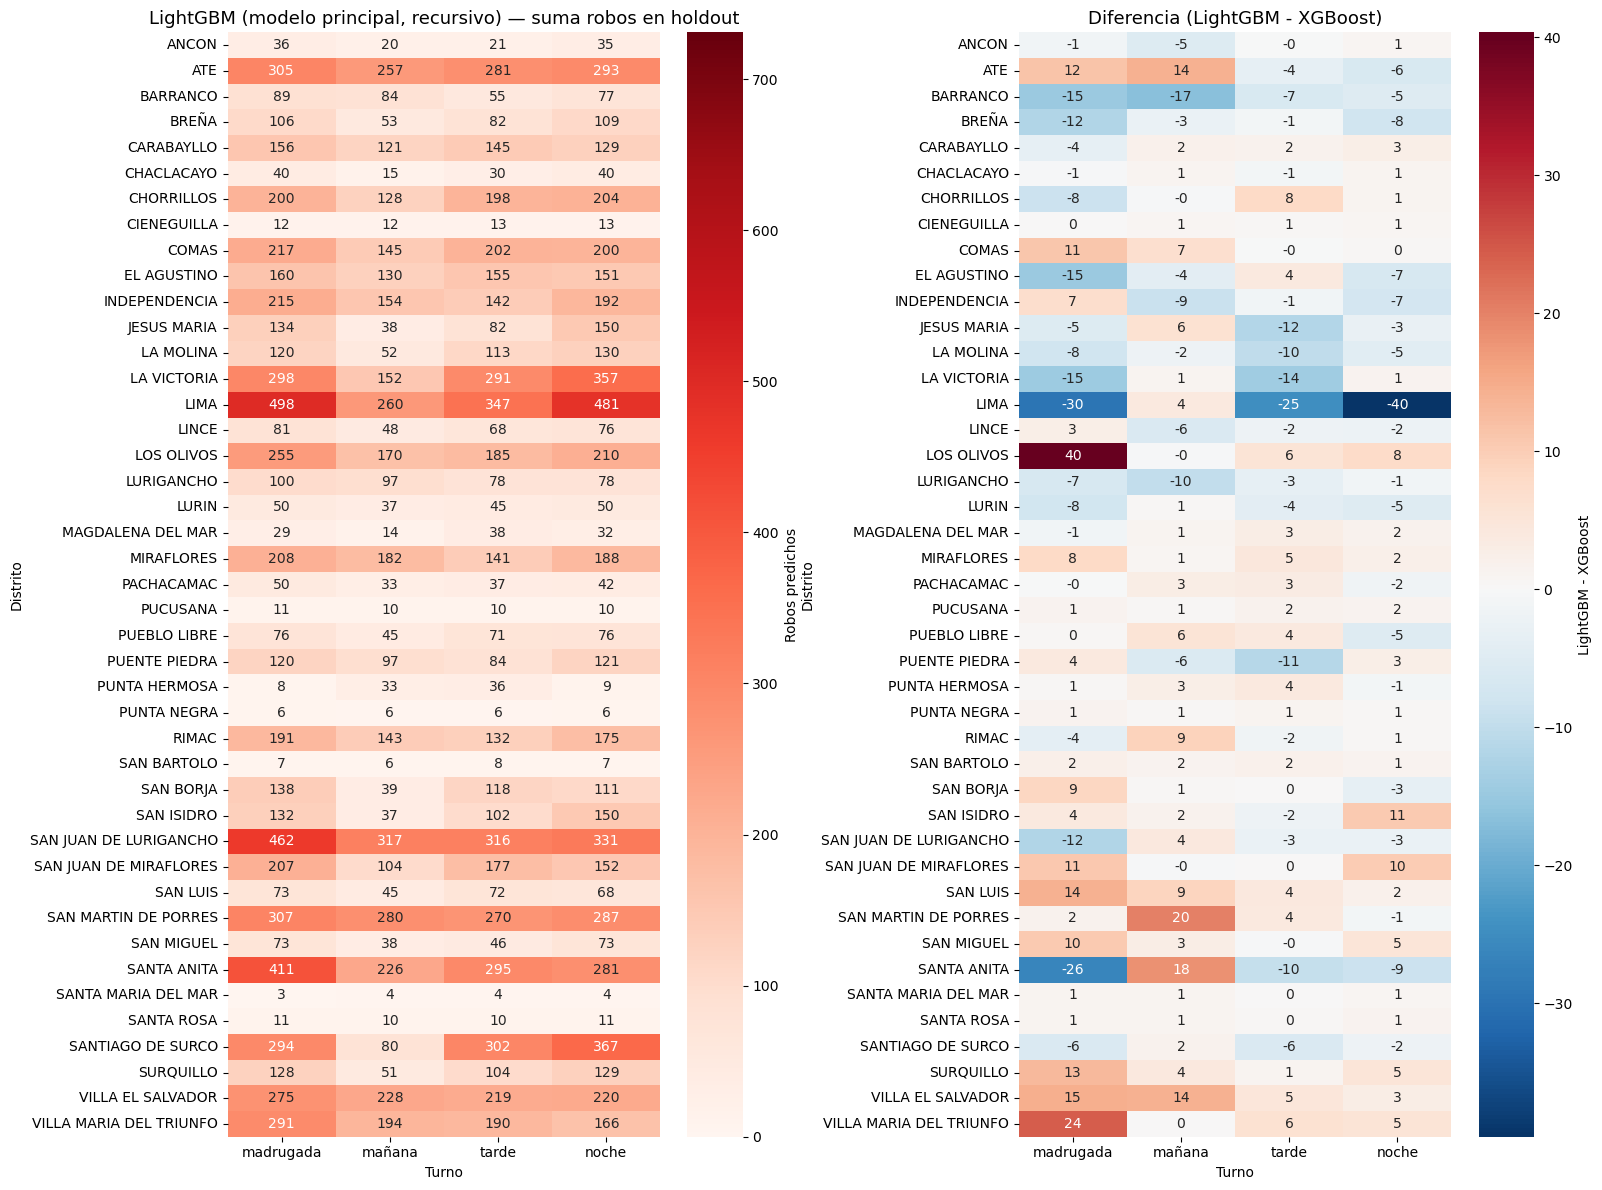

Error absoluto total de LightGBM: 6039
Error absoluto total de XGBoost:  6104
LightGBM gana tambien en el heatmap agregado.


In [27]:
# Comparativa head-to-head: heatmap del mejor modelo y diferencia
if columna_pred_alternativo in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 12))

    pivot_lgbm = (df.groupby(["distrito_hecho", "turno_hecho"])[columna_pred_principal]
                     .sum().reset_index()
                     .pivot(index="distrito_hecho", columns="turno_hecho", values=columna_pred_principal)
                     .fillna(0)[orden_turno])
    pivot_xgb = (df.groupby(["distrito_hecho", "turno_hecho"])[columna_pred_alternativo]
                    .sum().reset_index()
                    .pivot(index="distrito_hecho", columns="turno_hecho", values=columna_pred_alternativo)
                    .fillna(0)[orden_turno])

    vmax = max(pivot_real.values.max(), pivot_lgbm.values.max(), pivot_xgb.values.max())

    sns.heatmap(pivot_lgbm, annot=True, fmt=".0f", cmap="Reds", ax=axes[0],
                cbar_kws={"label": "Robos predichos"}, vmin=0, vmax=vmax)
    axes[0].set_title("LightGBM (modelo principal, recursivo) — suma robos en holdout", fontsize=13)
    axes[0].set_xlabel("Turno"); axes[0].set_ylabel("Distrito")

    diff = pivot_lgbm - pivot_xgb
    sns.heatmap(diff, annot=True, fmt=".0f", cmap="RdBu_r",
                center=0, ax=axes[1], cbar_kws={"label": "LightGBM - XGBoost"})
    axes[1].set_title("Diferencia (LightGBM - XGBoost)", fontsize=13)
    axes[1].set_xlabel("Turno"); axes[1].set_ylabel("Distrito")

    plt.tight_layout()
    plt.savefig(FIG_DIR / "heatmap_lightgbm_vs_xgb.png", dpi=120, bbox_inches="tight")
    plt.show()

    error_lgbm = (pivot_lgbm - pivot_real).abs().sum().sum()
    error_xgb  = (pivot_xgb  - pivot_real).abs().sum().sum()
    print(f"Error absoluto total de LightGBM: {error_lgbm:.0f}")
    print(f"Error absoluto total de XGBoost:  {error_xgb:.0f}")
    if error_lgbm < error_xgb:
        print("LightGBM gana tambien en el heatmap agregado.")

### Resumen del proyecto

Conclusion final del modelado:
- **LightGBM** es el mejor modelo en el esquema recursivo (apropiado para el producto).
- Las predicciones son recursivas en todo el pipeline, no single-step con observacion.
- El top-3 de zonas calientes: LIMA/tarde, LIMA/noche, SAN JUAN DE LURIGANCHO/noche.